In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
block_size = 3

def build_dataset(words):

    X, Y = [], []

    for w in words:

        context = [0] * block_size

        for ch in w + '.':
            ix = stoi[ch]

            X.append(context)
            Y.append(ix)

            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)

    print(X.shape, Y.shape)

    return X, Y

In [6]:
import random

random.seed(42)
random.shuffle(words)

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [7]:
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((27,10), generator=g)

W1 = torch.randn((30,200), generator=g)
b1 = torch.randn(200, generator=g)

W2 = torch.randn((200,27), generator=g)
b2 = torch.randn(27, generator=g)

parameters = [C, W1, b1, W2, b2]

sum(p.nelement() for p in parameters)

11897

In [8]:
for p in parameters:
    p.requires_grad = True

In [9]:
stepi = []
lossi = []

for i in range(200000):

    ix = torch.randint(0, Xtr.shape[0], (32,))

    emb = C[Xtr[ix]]

    h = torch.tanh(
        emb.view(-1,30) @ W1 + b1
    )

    logits = h @ W2 + b2

    loss = F.cross_entropy(logits, Ytr[ix])

    for p in parameters:
        p.grad = None

    loss.backward()

    lr = 0.1 if i < 100000 else 0.01

    for p in parameters:
        p.data += -lr * p.grad

    stepi.append(i)
    lossi.append(loss.log10().item())

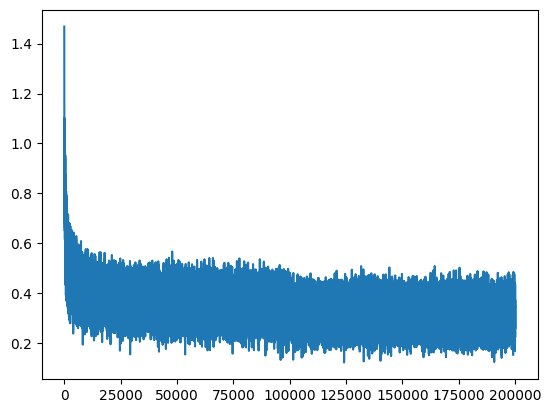

In [10]:
plt.plot(stepi, lossi)

In [11]:
emb = C[Xtr]

h = torch.tanh(
    emb.view(-1,30) @ W1 + b1
)

logits = h @ W2 + b2

loss = F.cross_entropy(logits, Ytr)

loss

tensor(2.1192, grad_fn=<NllLossBackward0>)

In [12]:
emb = C[Xdev]

h = torch.tanh(
    emb.view(-1,30) @ W1 + b1
)

logits = h @ W2 + b2

loss = F.cross_entropy(logits, Ydev)

loss

tensor(2.1573, grad_fn=<NllLossBackward0>)

In [13]:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size

    while True:

        emb = C[torch.tensor([context])]

        h = torch.tanh(
            emb.view(1,-1) @ W1 + b1
        )

        logits = h @ W2 + b2

        probs = F.softmax(logits, dim=1)

        ix = torch.multinomial(
            probs,
            num_samples=1,
            generator=g
        ).item()

        context = context[1:] + [ix]

        out.append(ix)

        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

carmahzatoriq.
khiem.
shreety.
salaysie.
rahmer.
deliah.
jareei.
ner.
kentziriivik.
legy.
dham.
porrielinn.
sulin.
alvin.
quinathoniearynix.
kaeuri.
sabee.
deci.
abette.
jasti.
